### The objective of this notebook is to create publication-ready forecast charts for the project write-up

In [2]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

In [3]:
# Defining a custom color palette
TEAL = "#0F4C5C" # Primary colour
TEAL_LIGHT = "#5A8A99"

ACCENT = "#C04000" # For highlights and / or forecasts
GREY = "#4A4A4A" # For actuals and / or neutral elements
LIGHT_GREY = "#B0B0B0"

# Custom color palette for multi-series plots
custom_palette = ["#0F4C5C",
                  "#C04000",
                  "#2E5A2E",
                  "#7B2D26",
                  "#3D5A80",
                  "#8B6F47",
                  "#5C4B51",
                  "#A4B494",
                  "#9B5DE5",
                  "#4A4A4A"] 
sns.set_theme(style = 'whitegrid', context = 'notebook',palette=custom_palette)

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.prop_cycle'] = plt.cycler(color = custom_palette)

In [15]:
from matplotlib.colors import LinearSegmentedColormap
teal_cmap = LinearSegmentedColormap.from_list('teal',['#F0F8F8','#1F8B8B'])

In [4]:
# Loading the output files
actuals = pd.read_csv('../data/processed/hierarchy_ready.csv')
actuals['ds'] = pd.to_datetime(actuals['ds'])
base_forecasts = pd.read_csv('../outputs/base_forecasts.csv')
base_forecasts['ds'] = pd.to_datetime(base_forecasts['ds'])
reconciled_forecasts = pd.read_csv('../outputs/reconciled_forecasts.csv')
reconciled_forecasts['ds'] = pd.to_datetime(reconciled_forecasts['ds'])
lightgbm_forecasts = pd.read_csv('../outputs/lightgbm_forecasts.csv')
lightgbm_forecasts['ds'] = pd.to_datetime(lightgbm_forecasts['ds'])
lightgbm_reconciled = pd.read_csv('../outputs/lightgbm_reconciled.csv')
lightgbm_reconciled['ds'] = pd.to_datetime(lightgbm_reconciled['ds'])

In [5]:
to_drop = {
    'TOTAL/MUMBAI/MUMBAI-RAJKOT',
    'TOTAL/DELHI/DELHI-RAJKOT',
    'TOTAL/DEHRA DUN/DEHRA DUN-DELHI',
    'TOTAL/DEHRA DUN'
}

actuals = actuals[~actuals['unique_id'].isin(to_drop)].copy()

In [6]:
print('actuals: ',actuals.shape)
print('base_forecasts: ',base_forecasts.shape)
print('reconciled_forecasts: ',reconciled_forecasts.shape)
print('lightgbm_forecasts: ',lightgbm_forecasts.shape)
print('lightgbm_reconciled: ',lightgbm_reconciled.shape)

actuals:  (26677, 3)
base_forecasts:  (2736, 6)
reconciled_forecasts:  (2736, 14)
lightgbm_forecasts:  (2736, 3)
lightgbm_reconciled:  (2736, 5)


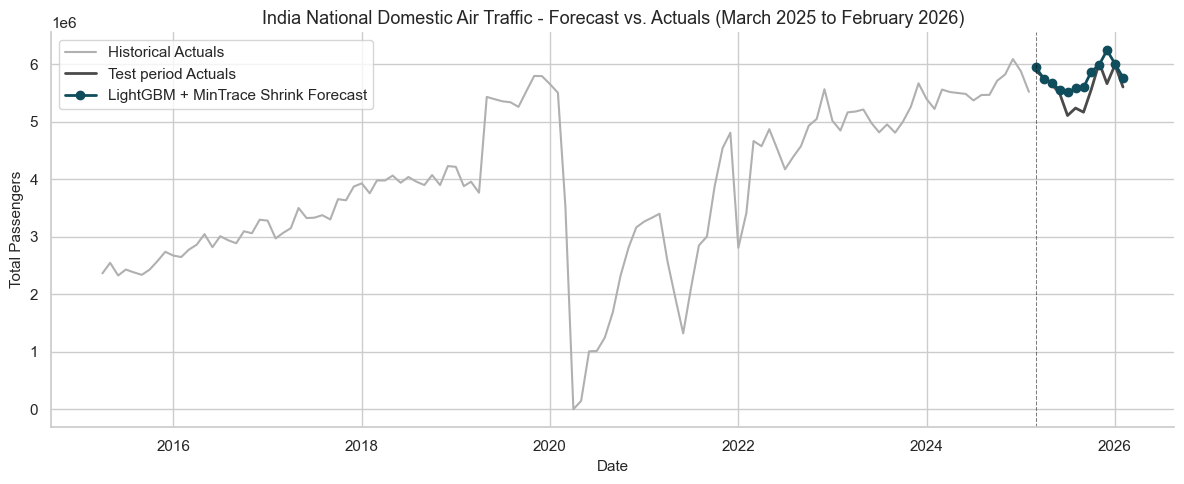

In [7]:
total_actuals = actuals[actuals['unique_id'] == 'TOTAL'].sort_values('ds')
total_forecast = lightgbm_reconciled[lightgbm_reconciled['unique_id'] == 'TOTAL'].sort_values('ds')

split_date = pd.Timestamp('2025-03-01')

train_actuals = total_actuals[total_actuals['ds'] < split_date]
test_actuals = total_actuals[total_actuals['ds'] >= split_date]

fig, ax = plt.subplots(figsize = (12,5))
ax.plot(train_actuals['ds'],train_actuals['y'],color = LIGHT_GREY, lw = 1.5, label = 'Historical Actuals')
ax.plot(test_actuals['ds'],test_actuals['y'], color = GREY, lw = 2, label = 'Test period Actuals')
ax.plot(total_forecast['ds'], total_forecast['LightGBM/MinTrace_method-mint_shrink'],color = TEAL, lw = 2, marker = 'o', label = 'LightGBM + MinTrace Shrink Forecast')
ax.axvline(split_date, color = 'black', lw = 0.75, ls = '--', alpha = 0.5)

ax.set_title('India National Domestic Air Traffic - Forecast vs. Actuals (March 2025 to February 2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Passengers')
ax.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig('../outputs/chart_national_forecast.png', dpi = 150, bbox_inches = 'tight')
plt.show()


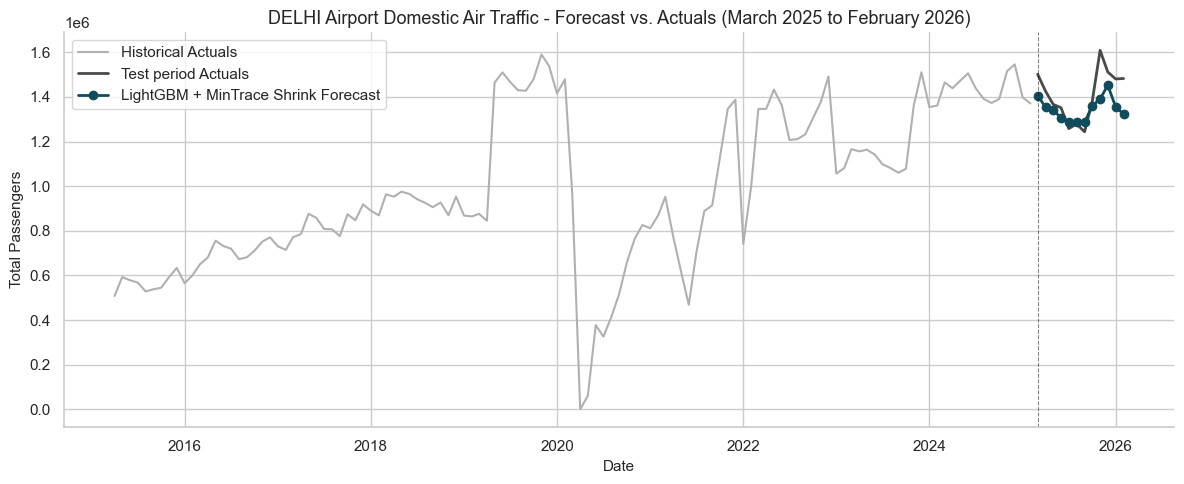

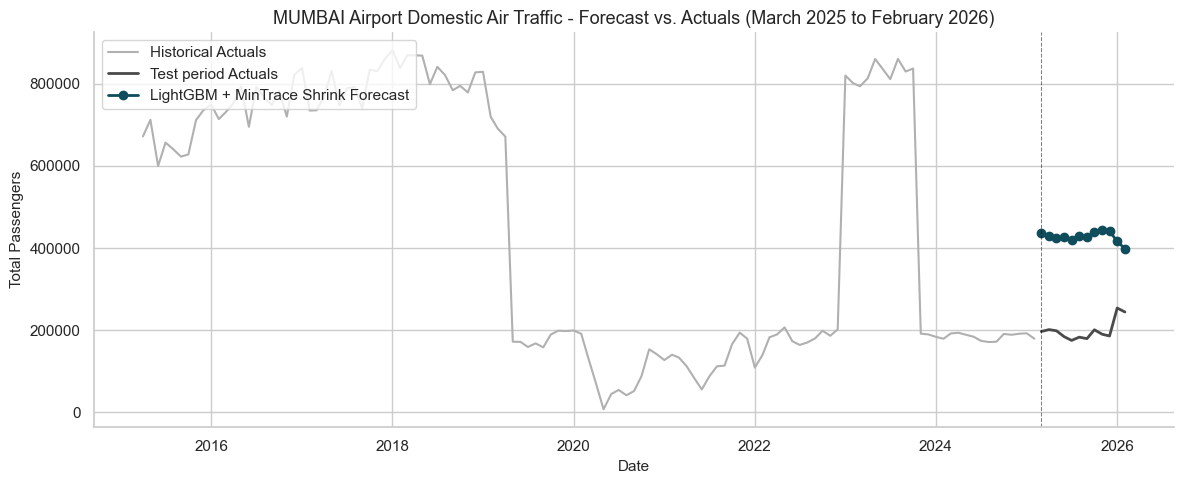

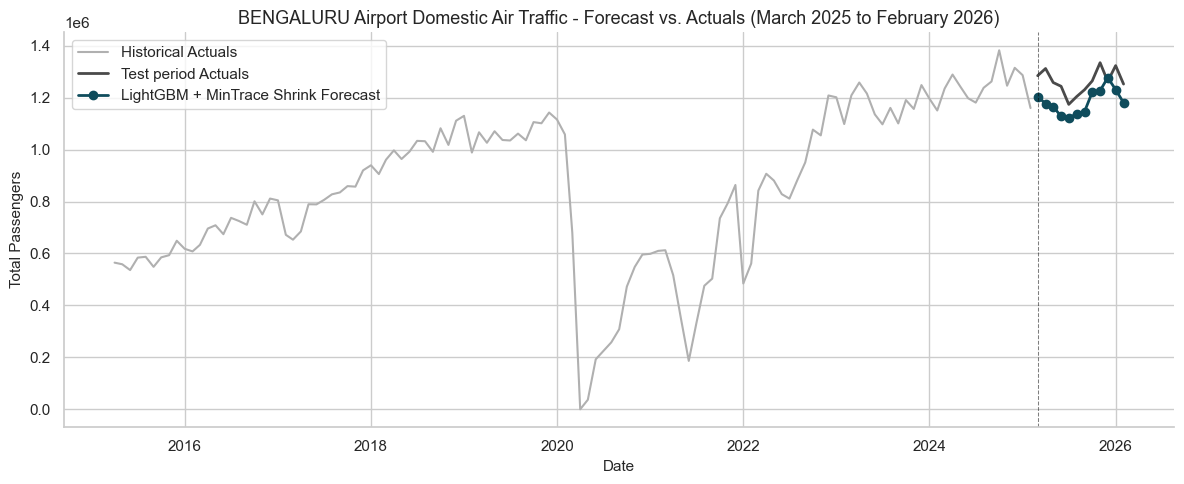

In [8]:
airports = ['DELHI', 'MUMBAI', 'BENGALURU']
for airport in airports:
    total_actuals = actuals[actuals['unique_id'] == f'TOTAL/{airport}'].sort_values('ds')
    total_forecast = lightgbm_reconciled[lightgbm_reconciled['unique_id'] == f'TOTAL/{airport}'].sort_values('ds')

    split_date = pd.Timestamp('2025-03-01')

    train_actuals = total_actuals[total_actuals['ds'] < split_date]
    test_actuals = total_actuals[total_actuals['ds'] >= split_date]

    fig, ax = plt.subplots(figsize = (12,5))
    ax.plot(train_actuals['ds'],train_actuals['y'],color = LIGHT_GREY, lw = 1.5, label = 'Historical Actuals')
    ax.plot(test_actuals['ds'],test_actuals['y'], color = GREY, lw = 2, label = 'Test period Actuals')
    ax.plot(total_forecast['ds'], total_forecast['LightGBM/MinTrace_method-mint_shrink'],color = TEAL, lw = 2, marker = 'o', label = 'LightGBM + MinTrace Shrink Forecast')
    ax.axvline(split_date, color = 'black', lw = 0.75, ls = '--', alpha = 0.5)

    ax.set_title(f'{airport} Airport Domestic Air Traffic - Forecast vs. Actuals (March 2025 to February 2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Passengers')
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.savefig(f'../outputs/chart_{airport}_airport_forecast.png', dpi = 150, bbox_inches = 'tight')
    plt.show()


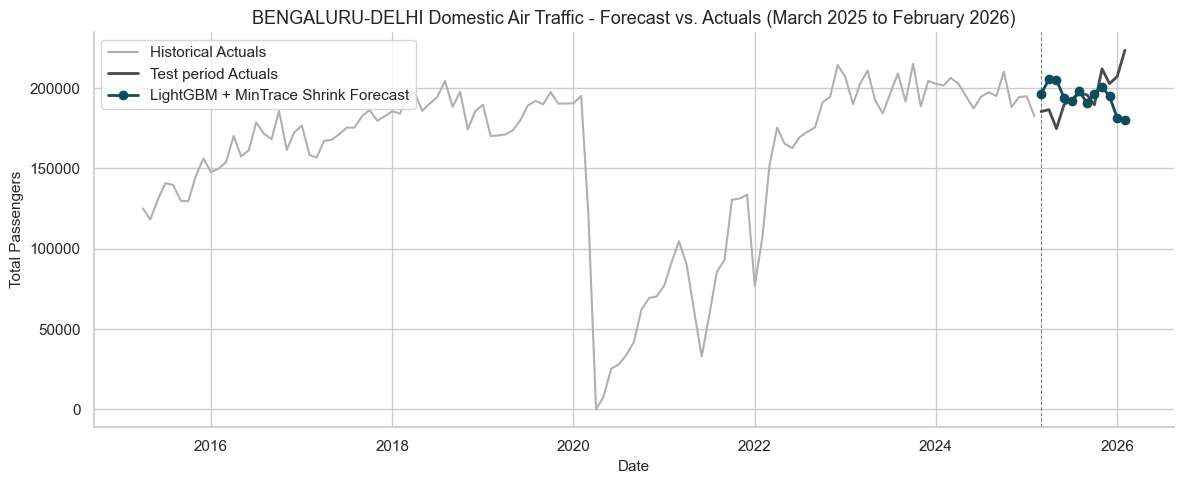

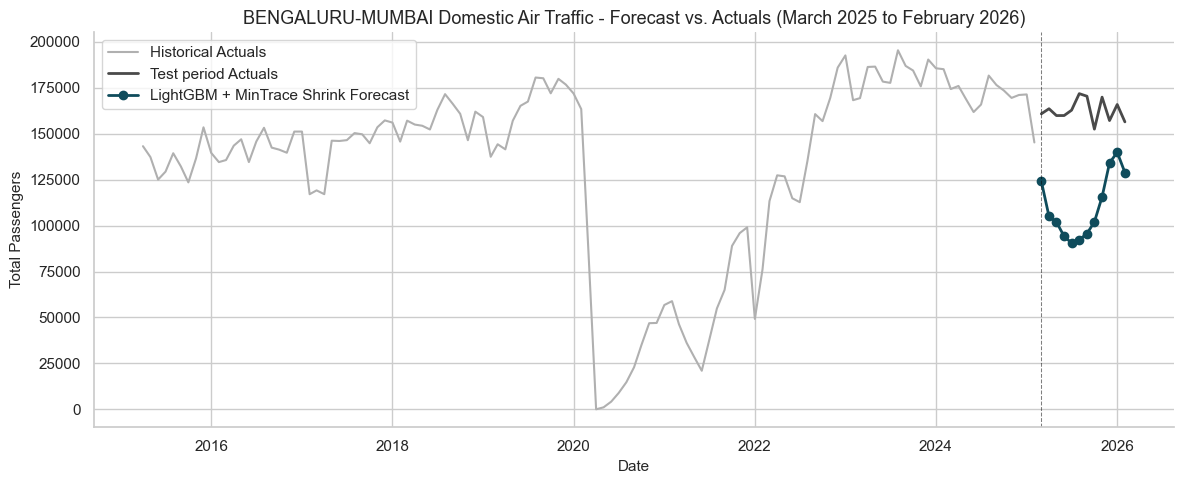

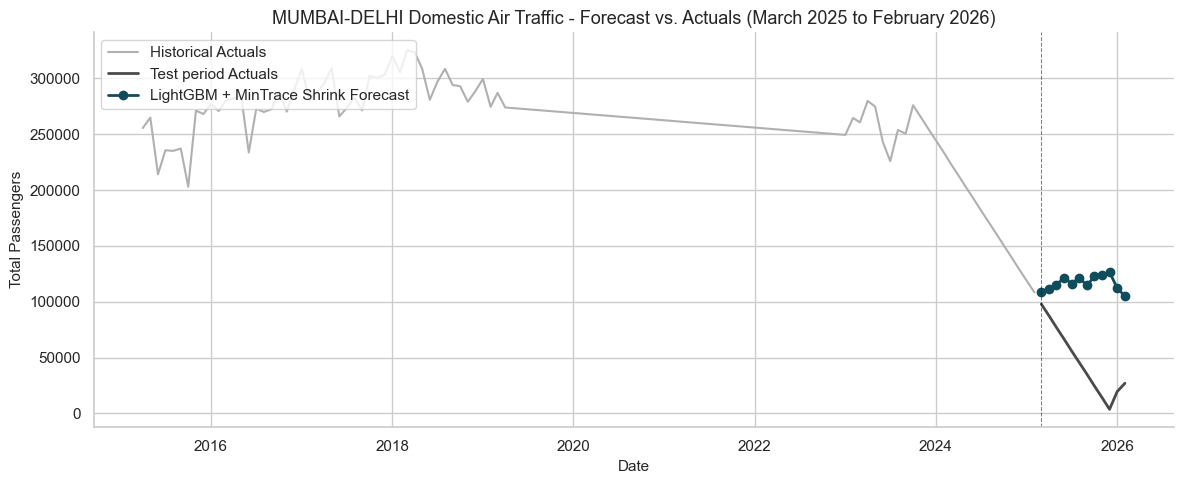

In [9]:
top_3_routes = ['BENGALURU-DELHI', 'BENGALURU-MUMBAI', 'MUMBAI-DELHI']
for route in top_3_routes:
    origin = route.split('-')[0]
    total_actuals = actuals[actuals['unique_id'] == f'TOTAL/{origin}/{route}'].sort_values('ds')
    total_forecast = lightgbm_reconciled[lightgbm_reconciled['unique_id'] == f'TOTAL/{origin}/{route}'].sort_values('ds')

    split_date = pd.Timestamp('2025-03-01')

    train_actuals = total_actuals[total_actuals['ds'] < split_date]
    test_actuals = total_actuals[total_actuals['ds'] >= split_date]

    fig, ax = plt.subplots(figsize = (12,5))
    ax.plot(train_actuals['ds'],train_actuals['y'],color = LIGHT_GREY, lw = 1.5, label = 'Historical Actuals')
    ax.plot(test_actuals['ds'],test_actuals['y'], color = GREY, lw = 2, label = 'Test period Actuals')
    ax.plot(total_forecast['ds'], total_forecast['LightGBM/MinTrace_method-mint_shrink'],color = TEAL, lw = 2, marker = 'o', label = 'LightGBM + MinTrace Shrink Forecast')
    ax.axvline(split_date, color = 'black', lw = 0.75, ls = '--', alpha = 0.5)

    ax.set_title(f'{route} Domestic Air Traffic - Forecast vs. Actuals (March 2025 to February 2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Passengers')
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.savefig(f'../outputs/chart_{route}_route_forecast.png', dpi = 150, bbox_inches = 'tight')
    plt.show()


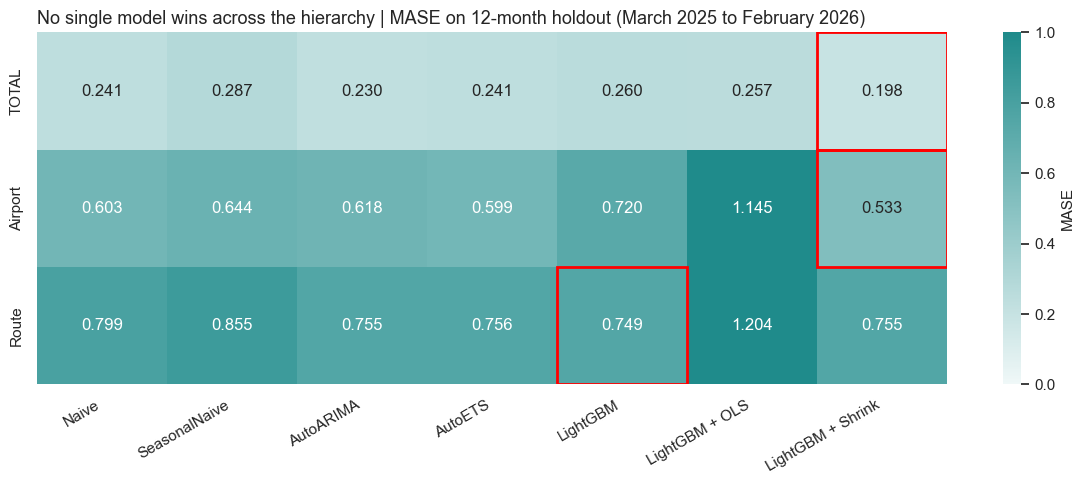

In [16]:
# For each level of the hierarchy, which model has the lowest MASE?

unified = pd.read_csv('../outputs/unified_summary.csv', index_col = 0)

unified = unified[~unified.index.duplicated(keep = 'first')]

rows = ['Naive','SeasonalNaive','AutoARIMA','AutoETS','LightGBM','LightGBM/MinTrace_method-ols','LightGBM/MinTrace_method-mint_shrink']

display_cols = ['Naive', 'SeasonalNaive','AutoARIMA','AutoETS','LightGBM','LightGBM + OLS','LightGBM + Shrink']

mase = unified.loc[rows, ['TOTAL','Airport','Route']].T

mase.columns = display_cols

fig, ax = plt.subplots(figsize = (12,5))

sns.heatmap(mase, annot = True, fmt = '0.3f', cmap = teal_cmap, vmin = 0, vmax = 1, cbar_kws = {'label':'MASE'}, ax = ax)

for i in range (mase.shape[0]):
    j_min = np.argmin(mase.values[i])
    ax.add_patch(Rectangle((j_min,i), 1, 1, fill = False, edgecolor = 'red', linewidth = 2))

ax.set_title('No single model wins across the hierarchy | MASE on 12-month holdout (March 2025 to February 2026)', loc = 'left')

plt.xticks(rotation = 30, ha = 'right')

plt.ylabel('')

plt.tight_layout()

plt.savefig('../outputs/heatmap_accuracy_comparison.png',dpi = 200)

plt.show()

In [18]:
base = pd.read_csv('../outputs/base_forecasts.csv')
recon = pd.read_csv('../outputs/reconciled_forecasts.csv')
full = pd.read_csv('../data/processed/hierarchy_ready.csv')

In [19]:
actuals = full[full['ds'] >= '2025-03-01']

# Filtering only the TOTAL 
base_total = base[base['unique_id'] == 'TOTAL'].copy()
recon_total = recon[recon['unique_id'] == 'TOTAL'].copy()
actuals_total = actuals[actuals['unique_id'] == 'TOTAL'].copy()

In [20]:
# Converting the ds field to date format
for df in [base_total, recon_total, actuals_total]:
    df['ds'] = pd.to_datetime(df['ds'])

In [21]:
def plot_reconciliation (base_df, actuals_df, recon_df, model_base_col, model_recon_col, model_label, save_path):
    fig, ax = plt.subplots(figsize = (12,5))

    ax.plot(actuals_df['ds'],actuals_df['y'], color = GREY, marker = 'o', linewidth = 2, label = 'Actuals')

    ax.plot(base_df['ds'],base_df[model_base_col], color = TEAL_LIGHT, marker = 's', linewidth = 2, label = f'{model_label} (base)')

    ax.plot(recon_df['ds'],recon_df[model_recon_col], color = TEAL, marker = '^', linewidth = 2, label = f'{model_label} + MinTrace Shrink')

    ax.set_title(f'Impact of MinTrace Shrink Reconciliation at National (TOTAL) level - {model_label}', loc = 'left')

    ax.set_xlabel('Month')

    ax.set_ylabel('Passengers')

    ax.legend(frameon = False)

    plt.xticks(rotation = 30, ha = 'right')

    plt.tight_layout()

    plt.savefig(save_path, dpi = 200)

    plt.show()

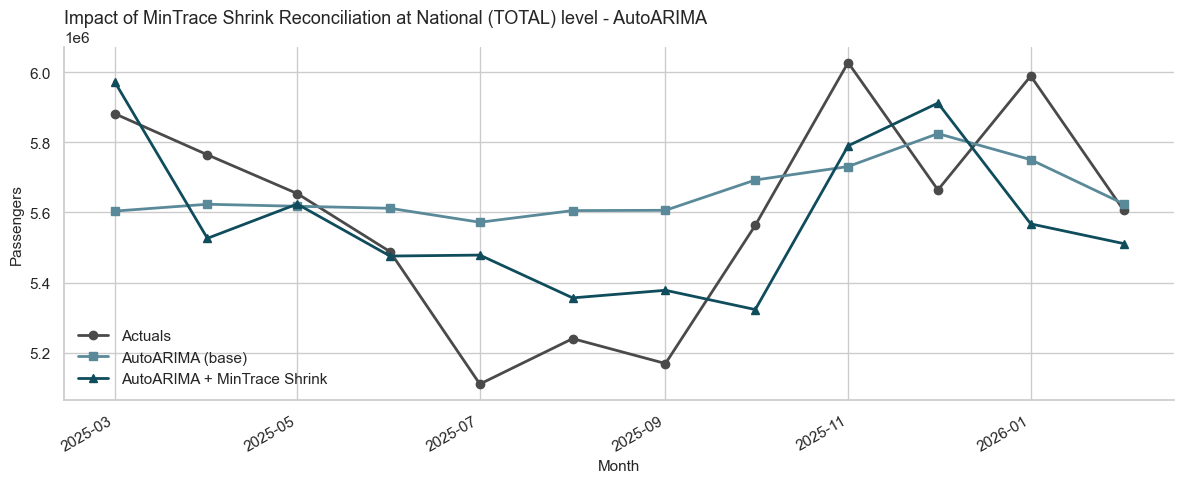

In [23]:
# AutoARIMA
plot_reconciliation(
    actuals_df = actuals_total,
    base_df = base_total,
    recon_df = recon_total,
    model_base_col = 'AutoARIMA',
    model_recon_col = 'AutoARIMA/MinTrace_method-mint_shrink',
    model_label = 'AutoARIMA',
    save_path = '../outputs/chart_reconciliation_impact_arima.png'
)

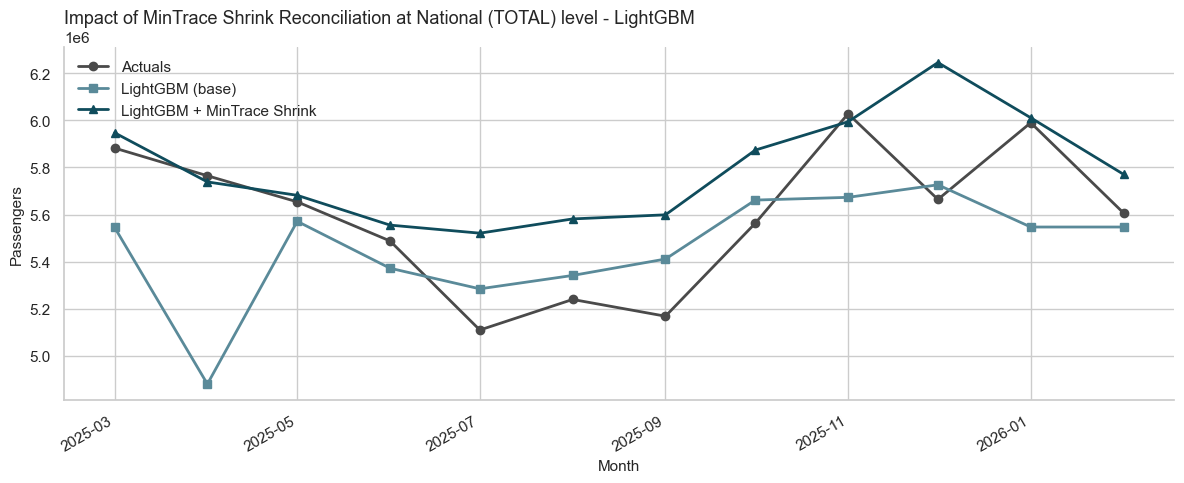

In [26]:
# LightGBM
lgb_base = pd.read_csv('../outputs/lightgbm_forecasts.csv')
lgb_recon = pd.read_csv('../outputs/lightgbm_reconciled.csv')

lgb_base_total = lgb_base[lgb_base['unique_id'] == 'TOTAL'].copy()
lgb_recon_total = lgb_recon[lgb_recon['unique_id'] == 'TOTAL'].copy()

lgb_base_total['ds'] = pd.to_datetime(lgb_base_total['ds'])
lgb_recon_total['ds'] = pd.to_datetime(lgb_recon_total['ds'])

plot_reconciliation(
    actuals_df = actuals_total,
    base_df = lgb_base_total,
    recon_df = lgb_recon_total,
    model_base_col = 'LightGBM',
    model_recon_col = 'LightGBM/MinTrace_method-mint_shrink',
    model_label = 'LightGBM',
    save_path = '../outputs/chart_reconciliation_impact_lightgbm.png'
)